# CIFAR-10 Backbone Karşılaştırması — Sonuç Analizi

ResNet-50 vs EfficientNet-B3 vs ConvNeXt-T transfer learning sonuçları. Bu notebook `results/*.json` dosyalarını okuyup özet tablo ve grafikler üretir. Şu an **ResNet-50** ve **EfficientNet-B3** eğitimleri tamamlandı; ConvNeXt-T bitince tablo/grafikler otomatik güncellenecek (hücreleri yeniden çalıştırman yeterli).

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results")
result_files = sorted(RESULTS_DIR.glob("*.json"))

results = {}
for f in result_files:
    with open(f) as fh:
        results[f.stem] = json.load(fh)

print(f"Bulunan sonuçlar: {list(results.keys())}")

Bulunan sonuçlar: ['efficientnet_b3', 'resnet50']


## Özet Tablo

In [2]:
rows = []
for name, r in results.items():
    epoch_times = r["history"]["epoch_time_sec"]
    rows.append({
        "model": r["model"],
        "num_params": r["num_params"],
        "best_val_acc": r["best_val_acc"],
        "final_val_acc": r["final_val_acc"],
        "total_train_time_min": r["total_train_time_sec"] / 60,
        "avg_epoch_time_sec": sum(epoch_times) / len(epoch_times),
        "median_epoch_time_sec": sorted(epoch_times)[len(epoch_times) // 2],
    })

summary = pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
summary

,model,num_params,best_val_acc,final_val_acc,total_train_time_min,avg_epoch_time_sec,median_epoch_time_sec
0,efficientnet_b3,10711602,0.9819,0.9809,158.873477,381.230182,353.191556
1,resnet50,23528522,0.9734,0.9725,209.675161,503.117383,312.121719


## ResNet-50 — Detaylı Sonuç

| Metrik | Değer |
|---|---|
| Parametre sayısı | 23,528,522 (~23.5M) |
| En iyi val_acc | **%97.34** (epoch 23) |
| Son epoch val_acc | %97.25 (epoch 25) |
| Toplam eğitim süresi | 12,580s (~209.7 dk / ~3.5 saat) |
| Ortalama epoch süresi | ~503s (2 epoch'ta anormal yavaşlama dahil, medyan ~340s daha temsili) |
| Batch size | 64 |

## EfficientNet-B3 — Detaylı Sonuç

| Metrik | Değer |
|---|---|
| Parametre sayısı | 10,711,602 (~10.7M) |
| En iyi val_acc | **%98.19** (epoch 22) |
| Son epoch val_acc | %98.09 (epoch 25) |
| Toplam eğitim süresi | 9,532s (~158.9 dk / ~2.6 saat) |
| Ortalama epoch süresi | ~381s (medyan ~353s) |
| Batch size | 32 |

### Yorum: ResNet-50 vs EfficientNet-B3

- **Doğruluk**: EfficientNet-B3, ResNet-50'yi **%0.85 puan** farkla geçti (%98.19 vs %97.34) — CIFAR-10'a transfer learning ile aktarılan ImageNet ağırlıkları açısından EfficientNet mimarisinin (compound scaling + MBConv blokları) bu görevde biraz daha iyi genelleştiği görülüyor.
- **Parametre verimliliği**: EfficientNet-B3, ResNet-50'nin parametre sayısının **~%45'i** ile (10.7M vs 23.5M) daha yüksek doğruluk elde etti — parametre başına çok daha verimli.
- **Eğitim süresi**: Daha küçük batch size'a (32 vs 64, VRAM kısıtı nedeniyle) rağmen EfficientNet-B3 toplamda daha **hızlı** tamamlandı (~2.6 saat vs ~3.5 saat) — bunun büyük kısmı ResNet-50 çalışmasında rastlanan iki anormal yavaşlama epoch'undan (14. ve 19. epoch, muhtemelen arka planda sistem kaynak çakışması) kaynaklanıyor; medyan epoch süreleri (312s vs 353s) aslında ResNet-50'nin adım başına biraz daha hızlı olduğunu gösteriyor.
- **Yakınsama**: EfficientNet-B3 val_acc eğrisi daha az dalgalı ve epoch 20 civarında platoya ulaşıyor; ResNet-50 ise epoch 22-23'e kadar iyileşmeye devam etti.

### Canlı wandb Kayıtları (metrik + GPU kullanımı grafikleri)

Tüm koşuların canlı metrik eğrileri ve GPU kullanım/güç/bellek grafikleri (sistem izleme sekmesi) wandb projesinde görüntülenebilir:

- **Proje (tüm run'lar)**: https://wandb.ai/sumeyyesaray478-mu-la-s-tk-ko-man-niversitesi/backbone-comparison
- **ResNet-50 run**: https://wandb.ai/sumeyyesaray478-mu-la-s-tk-ko-man-niversitesi/backbone-comparison/runs/6qlg1y9i
- **EfficientNet-B3 run**: https://wandb.ai/sumeyyesaray478-mu-la-s-tk-ko-man-niversitesi/backbone-comparison/runs/dde3bt5j

Run sayfasındaki **System** sekmesinde GPU Memory/SM Clock, Power Usage (W/%) ve GPU Memory Allocated grafikleri yer alıyor — RTX 3050 Laptop (4GB VRAM) üzerindeki gerçek kullanım paternini gösteriyor (batch başına periyodik yük artışı, ResNet-50'de görülen ~14. ve ~19. epoch'taki anormal yavaşlamalarla örtüşen düşük GPU kullanım aralıkları dahil).

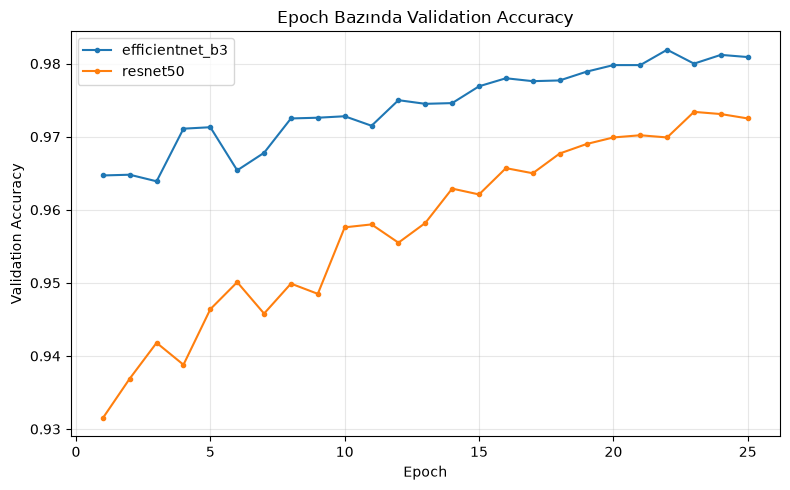

In [3]:
def plot_metric(results, metric, ylabel, title):
    plt.figure(figsize=(8, 5))
    for name, r in results.items():
        plt.plot(range(1, len(r["history"][metric]) + 1), r["history"][metric], label=r["model"], marker="o", markersize=3)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_metric(results, "val_acc", "Validation Accuracy", "Epoch Bazında Validation Accuracy")

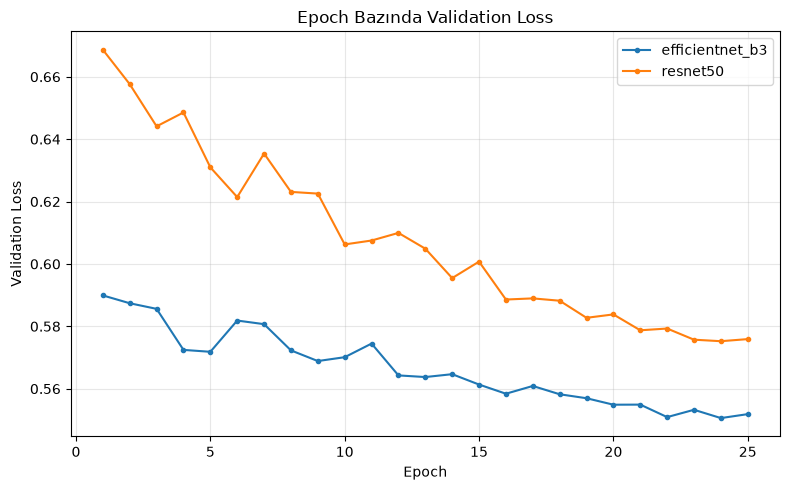

In [4]:
plot_metric(results, "val_loss", "Validation Loss", "Epoch Bazında Validation Loss")

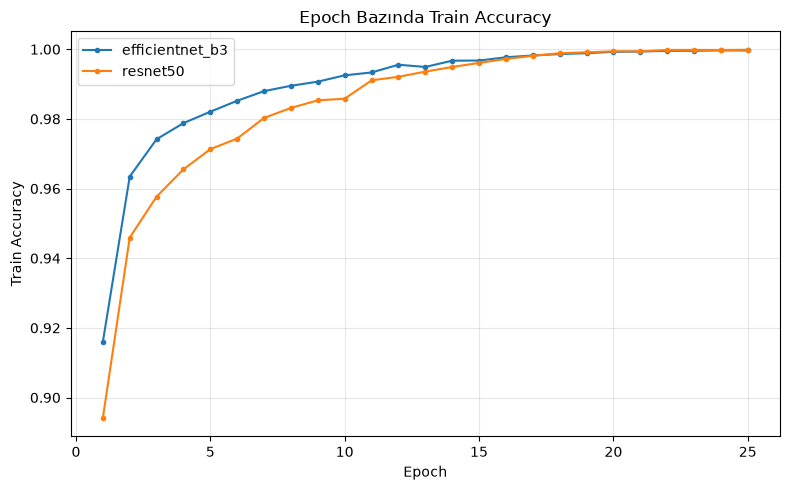

In [5]:
plot_metric(results, "train_acc", "Train Accuracy", "Epoch Bazında Train Accuracy")

## Parametre Sayısı vs Best Val Acc

Tüm modeller bittiğinde parametre-verimlilik karşılaştırması için.

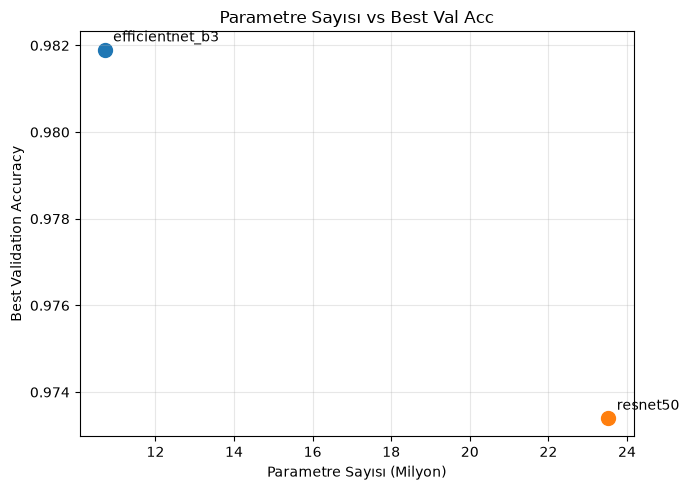

In [6]:
plt.figure(figsize=(7, 5))
for name, r in results.items():
    plt.scatter(r["num_params"] / 1e6, r["best_val_acc"], s=100)
    plt.annotate(r["model"], (r["num_params"] / 1e6, r["best_val_acc"]), textcoords="offset points", xytext=(6, 6))
plt.xlabel("Parametre Sayısı (Milyon)")
plt.ylabel("Best Validation Accuracy")
plt.title("Parametre Sayısı vs Best Val Acc")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()